In [4]:
import numpy as np

# Función de activación clásica para redes neuronales
def sigmoide(x):
    return 1 / (1 + np.exp(-np.clip(x, -10, 10)))

# 1. Corpus
corpus = [
    "el rey vive en el palacio",
    "la reina vive en el palacio",
    "el rey tiene una corona",
    "la reina tiene una corona"
]

# 2. Vocabulario
palabras = list(set(" ".join(corpus).split()))
word2idx = {palabra: i for i, palabra in enumerate(palabras)}
vocab_size = len(palabras)

# 3. Hiperparámetros
EMBEDDING_DIM = 2
LEARNING_RATE = 0.2
EPOCAS = 2000

# Word2Vec real usa dos matrices: una para palabras foco (W1) y otra para contexto (W2)
# Esto rompe la simetría por completo y evita el colapso
W_foco = np.random.uniform(-0.8, 0.8, (vocab_size, EMBEDDING_DIM))
W_contexto = np.random.uniform(-0.8, 0.8, (vocab_size, EMBEDDING_DIM))

# 4. Entrenamiento con arquitectura Skip-Gram Simplificada
for epoca in range(EPOCAS):
    for frase in corpus:
        palabras_frase = frase.split()
        for i, palabra_foco in enumerate(palabras_frase):
            idx_foco = word2idx[palabra_foco]

            # Ventana de contexto (1 palabra izquierda y derecha)
            vecinos = [palabras_frase[j] for j in [i-1, i+1] if 0 <= j < len(palabras_frase)]

            for vecino in vecinos:
                idx_contexto = word2idx[vecino]

                # Forward Pass: Medimos la afinidad actual entre las dos palabras (Producto punto)
                afinidad = np.dot(W_foco[idx_foco], W_contexto[idx_contexto])
                prediccion = sigmoide(afinidad)

                # El objetivo es que la predicción sea 1 (porque son vecinas reales)
                error = 1.0 - prediccion

                # Backward Pass: Calculamos gradientes y actualizamos ambas matrices por separado
                grad_foco = error * W_contexto[idx_contexto]
                grad_contexto = error * W_foco[idx_foco]

                W_foco[idx_foco] += LEARNING_RATE * grad_foco
                W_contexto[idx_contexto] += LEARNING_RATE * grad_contexto

# Usamos la matriz de foco como nuestros embeddings finales
print("--- EMBEDDINGS REALES APRENDIDOS ---")
for palabra, idx in word2idx.items():
    vector = W_foco[idx]
    print(f"{palabra:10} -> X: {vector[0]:.4f}, Y: {vector[1]:.4f}")

--- EMBEDDINGS REALES APRENDIDOS ---
la         -> X: -0.4682, Y: 2.7540
vive       -> X: 2.5589, Y: 2.3596
reina      -> X: 1.3289, Y: -3.2848
el         -> X: 3.2158, Y: 1.8639
palacio    -> X: 2.5669, Y: -0.4516
una        -> X: -1.3837, Y: -3.2345
corona     -> X: -0.6309, Y: 2.7032
tiene      -> X: 1.1705, Y: 3.1916
rey        -> X: 2.2059, Y: -2.5565
en         -> X: 2.9946, Y: -0.8296


reina      -> X: 1.3289, Y: -3.2848

rey        -> X: 2.2059, Y: -2.5565


Repetimos el proceso de entrenamiento pero con un corpus de 300 registros

In [5]:
entrenamiento_300 = [
    # --- Bloque 1: Monarquía y Roles del Palacio ---
    "el rey vive en el palacio", "la reina vive en el palacio", "el principe vive en el palacio", "la princesa vive en el palacio",
    "el rey tiene una corona", "la reina tiene una corona", "el principe tiene una corona", "la princesa tiene una corona",
    "el rey gobierna el gran reino", "la reina gobierna el gran reino", "el principe gobierna el gran reino", "la princesa gobierna el gran reino",
    "el rey habla con el duque", "la reina habla con el duque", "el principe habla con el duque", "la princesa habla con el duque",
    "el rey lidera el imperio", "la reina lidera el imperio", "el principe lidera el imperio", "la princesa lidera el imperio",
    "el duque vive en el castillo", "el conde vive en el castillo", "el baron vive en el castillo", "el lord vive en el castillo",
    "el duque tiene un feudo", "el conde tiene un feudo", "el baron tiene un feudo", "el lord tiene un feudo",
    "el duque sirve al rey", "el conde sirve al rey", "el baron sirve al rey", "el lord sirve al rey",
    "el rey otorga tierras al duque", "la reina otorga tierras al conde", "el principe otorga tierras al baron",
    "el palacio es enorme", "el castillo es antiguo", "la fortaleza es fuerte", "la torre es alta",
    "el rey viste una capa", "la reina viste una capa", "el principe viste una capa", "la princesa viste una capa",
    "el rey se sienta en el trono", "la reina se sienta en el trono", "el principe se sienta en el trono", "la princesa se sienta en el trono",
    "el trono es de oro", "la corona es de oro", "el anillo es de oro", "el cetro es de oro",
    "el sirviente limpia el palacio", "el sirviente limpia el castillo", "el sirviente limpia la torre",
    "el bufon divierte al rey", "el bufon divierte a la reina", "el bufon divierte al principe",
    "el heraldo anuncia al rey", "el heraldo anuncia a la reina", "el heraldo anuncia al duque",

    # --- Bloque 2: Caballeros, Armas y Batallas ---
    "el caballero protege el palacio", "el guardian protege el palacio", "el soldado el protege palacio", "el guardia protege el palacio",
    "el caballero protege el castillo", "el guardian protege el castillo", "el soldado protege el castillo", "el guardia protege el castillo",
    "el caballero protege al rey", "el guardian protege a la reina", "el soldado protege al principe", "el guardia protege a la princesa",
    "el caballero blande una espada", "el soldado blande una espada", "el guerrero blande una espada", "el campeon blande una espada",
    "el caballero blande un hacha", "el soldado blande un hacha", "el guerrero blande un hacha", "el campeon blande un hacha",
    "el caballero blande una lanza", "el soldado blande una lanza", "el guerrero blande una lanza", "el campeon blande una lanza",
    "el caballero viste una armadura", "el soldado viste una armadura", "el guerrero viste una armadura", "el guardia viste una armadura",
    "el caballero lleva un escudo", "el soldado lleva un escudo", "el guerrero lleva un escudo", "el guardia lleva un escudo",
    "la espada es de acero", "el hacha es de acero", "la lanza es de acero", "el escudo es de acero",
    "la armadura es de acero", "el casco es de acero", "la daga es de acero", "la maza es de acero",
    "el arquero dispara una flecha", "el ballestero dispara una flecha", "el tirador dispara una flecha",
    "el arquero tiene un arco", "el ballestero tiene un arco", "el tirador tiene un arco",
    "el caballero monta un caballo", "el guerrero monta un caballo", "el heroe monta un caballo",
    "el heroe lucha en la batalla", "el guerrero lucha en la batalla", "el soldado lucha en la batalla",
    "el heroe defiende el reino", "el guerrero defiende el reino", "el caballero defiende el reino",
    "la guerra destruye el feudo", "la batalla destruye el feudo", "el asedio destruye el feudo",

    # --- Bloque 3: Magia, Hechicería y Elementos ---
    "el mago vive en la torre", "el hechicero vive en la torre", "el brujo vive en la torre", "el alquimista vive en la torre",
    "el mago lee el libro", "el hechicero lee el libro", "el brujo lee el libro", "el alquimista lee el libro",
    "el mago lanza un hechizo", "el hechicero lanza un hechizo", "el brujo lanza un hechizo", "el nigromante lanza un hechizo",
    "el mago crea una pocion", "el hechicero crea una pocion", "el brujo crea una pocion", "el alquimista crea una pocion",
    "el mago usa su magia", "el hechicero usa su magia", "el brujo usa su magia", "el nigromante usa su magia",
    "el mago controla el fuego", "el hechicero controla el fuego", "el brujo controla el fuego",
    "el mago controla el hielo", "el hechicero controla el hielo", "el brujo controla el hielo",
    "el mago controla el rayo", "el hechicero controla el rayo", "el brujo controla el rayo",
    "el libro contiene runas", "el pergamino contiene runas", "la piedra contiene runas",
    "la magia requiere energia", "el hechizo requiere energia", "el ritual requiere energia",
    "el alquimista busca el elixir", "el mago busca el elixir", "el sabio busca el elixir",
    "el nigromante invoca un espectro", "el brujo invoca un espectro", "el hechicero invoca un espectro",
    "el baston canaliza el fuego", "la varita canaliza el fuego", "el amuleto canaliza el fuego",
    "el baston canaliza la magia", "la varita canaliza la magia", "el amuleto canaliza la magia",
    "la pocion cura al caballero", "el elixir cura al caballero", "la magia cura al caballero",
    "la pocion brilla en la oscuridad", "el elixir brilla en la oscuridad", "el cristal brilla en la oscuridad",

    # --- Bloque 4: Criaturas Fantásticas y Naturaleza ---
    "el dragon vuela sobre el reino", "el grifo vuela sobre el reino", "el fenix vuela sobre el reino",
    "el dragon vuela sobre el castillo", "el grifo vuela sobre el castillo", "el fenix vuela sobre el castillo",
    "el dragon escupe fuego", "el monstruo escupe fuego", "la bestia escupe fuego",
    "el dragon vive en la montaña", "el trol vive en la montaña", "el gigante vive en la montaña",
    "el trol vive en la cueva", "el goblin vive en la cueva", "el ogro vive en la cueva",
    "el trol ataca al viajero", "el goblin ataca al viajero", "el ogro ataca al viajero",
    "el elfo vive en el bosque", "el hada vive en el bosque", "el centauro vive en el bosque",
    "el elfo protege la naturaleza", "el hada protege la naturaleza", "el druida protege la naturaleza",
    "el elfo usa un arco", "el explorador usa un arco", "el cazador usa un arco",
    "el orco odia al rey", "el trol odia al rey", "el goblin odia al rey",
    "el orco ataca la fortaleza", "el gigante ataca la fortaleza", "el monstruo ataca la fortaleza",
    "el unicornio corre en el bosque", "el ciervo corre en el bosque", "el lobo corre en el bosque",
    "el dragon guarda el tesoro", "el monstruo guarda el tesoro", "el ogro guarda el tesoro",
    "el tesoro tiene oro", "el cofre tiene oro", "la bolsa tiene oro",
    "la montaña es alta", "la cueva es oscura", "el bosque es antiguo",

    # --- Bloque 5: Oficios, Aldeanos y Economía ---
    "el herrero forja la espada", "el herrero forja el hacha", "el herrero forja la lanza", "el herrero forja la daga",
    "el herrero trabaja en la forja", "el artesano trabaja en la forja", "el aprendiz trabaja en la forja",
    "el herrero vende acero", "el mercader vende acero", "el comerciante vende acero",
    "el mercader vende trigo", "el comerciante vende trigo", "el granjero vende trigo",
    "el granjero cultiva el campo", "el aldeano cultiva el campo", "el campesino cultiva el campo",
    "el granjero vive en la aldea", "el aldeano vive en la aldea", "el campesino vive en la aldea",
    "el granjero tiene un caballo", "el aldeano tiene un caballo", "el campesino tiene un caballo",
    "el panadero hace el pan", "el aldeano come el pan", "el campesino hace el pan",
    "el tabernero sirve la bebida", "el viajero compra la bebida", "el mercader toma la bebida",
    "la aldea es pacifica", "el pueblo es grande", "el mercado es ruidoso",
    "el mercader viaja en el camino", "el viajero viaja en el camino", "el caballero viaja en el camino",
    "el comerciante cuenta el oro", "el mercader cuenta el oro", "el ladron roba el oro",
    "el ladron usa una daga", "el asesino usa una daga", "el espia usa una daga",
    "el ladron se esconde en la oscuridad", "el espia se esconde en la oscuridad", "el asesino se esconde en la oscuridad",
    "el rey cobra impuestos a la aldea", "el duque cobra impuestos al pueblo",
    "el herrero usa el martillo", "el minero usa el pico", "el leñador usa el hacha"
]

corpus_limpio = [oracion.lower().replace(",", "").replace(".", "") for oracion in entrenamiento_300]



In [6]:

# 2. Vocabulario
palabras = list(set(" ".join(corpus_limpio).split()))
word2idx = {palabra: i for i, palabra in enumerate(palabras)}
vocab_size = len(palabras)

# 3. Hiperparámetros
EMBEDDING_DIM = 2
LEARNING_RATE = 0.2
EPOCAS = 2000

# Word2Vec real usa dos matrices: una para palabras foco (W1) y otra para contexto (W2)
# Esto rompe la simetría por completo y evita el colapso
W_foco = np.random.uniform(-0.8, 0.8, (vocab_size, EMBEDDING_DIM))
W_contexto = np.random.uniform(-0.8, 0.8, (vocab_size, EMBEDDING_DIM))

# 4. Entrenamiento con arquitectura Skip-Gram Simplificada
for epoca in range(EPOCAS):
    for frase in corpus:
        palabras_frase = frase.split()
        for i, palabra_foco in enumerate(palabras_frase):
            idx_foco = word2idx[palabra_foco]

            # Ventana de contexto (1 palabra izquierda y derecha)
            vecinos = [palabras_frase[j] for j in [i-1, i+1] if 0 <= j < len(palabras_frase)]

            for vecino in vecinos:
                idx_contexto = word2idx[vecino]

                # Forward Pass: Medimos la afinidad actual entre las dos palabras (Producto punto)
                afinidad = np.dot(W_foco[idx_foco], W_contexto[idx_contexto])
                prediccion = sigmoide(afinidad)

                # El objetivo es que la predicción sea 1 (porque son vecinas reales)
                error = 1.0 - prediccion

                # Backward Pass: Calculamos gradientes y actualizamos ambas matrices por separado
                grad_foco = error * W_contexto[idx_contexto]
                grad_contexto = error * W_foco[idx_foco]

                W_foco[idx_foco] += LEARNING_RATE * grad_foco
                W_contexto[idx_contexto] += LEARNING_RATE * grad_contexto

# Usamos la matriz de foco como nuestros embeddings finales
print("--- EMBEDDINGS REALES APRENDIDOS ---")
for palabra, idx in word2idx.items():
    vector = W_foco[idx]
    print(f"{palabra:10} -> X: {vector[0]:.4f}, Y: {vector[1]:.4f}")

--- EMBEDDINGS REALES APRENDIDOS ---
rayo       -> X: -0.2693, Y: 0.3056
unicornio  -> X: -0.4820, Y: -0.0785
princesa   -> X: 0.2523, Y: 0.6536
compra     -> X: 0.0168, Y: -0.4272
divierte   -> X: 0.3239, Y: 0.6099
gran       -> X: -0.3626, Y: 0.5093
trabaja    -> X: 0.1691, Y: 0.5285
batalla    -> X: -0.3274, Y: -0.1112
oscura     -> X: 0.7931, Y: 0.5574
artesano   -> X: -0.4910, Y: -0.6992
grande     -> X: -0.3749, Y: 0.5731
es         -> X: -0.1645, Y: 0.1632
bosque     -> X: 0.4356, Y: -0.1955
bufon      -> X: 0.6528, Y: 0.6504
guardia    -> X: 0.1744, Y: -0.1570
pan        -> X: -0.5799, Y: -0.1075
la         -> X: 0.5870, Y: -3.2903
el         -> X: 3.8194, Y: -0.0600
lleva      -> X: 0.7972, Y: 0.7038
lidera     -> X: -0.3516, Y: -0.3207
fortaleza  -> X: 0.0690, Y: -0.0644
armadura   -> X: 0.2313, Y: -0.4890
dragon     -> X: -0.2766, Y: 0.2461
sirve      -> X: 0.7860, Y: -0.4181
odia       -> X: -0.7914, Y: -0.2078
contiene   -> X: 0.1586, Y: 0.6988
fuerte     -> X: 0.2801, Y: 

rey        -> X: 3.3152, Y: -0.5628

reina      -> X: 3.4683, Y: 0.0848


Se puede apreciar como al mejorar el set de datos de entrenamiento el vector rey y el vector reina comenzaron a acercarse

<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

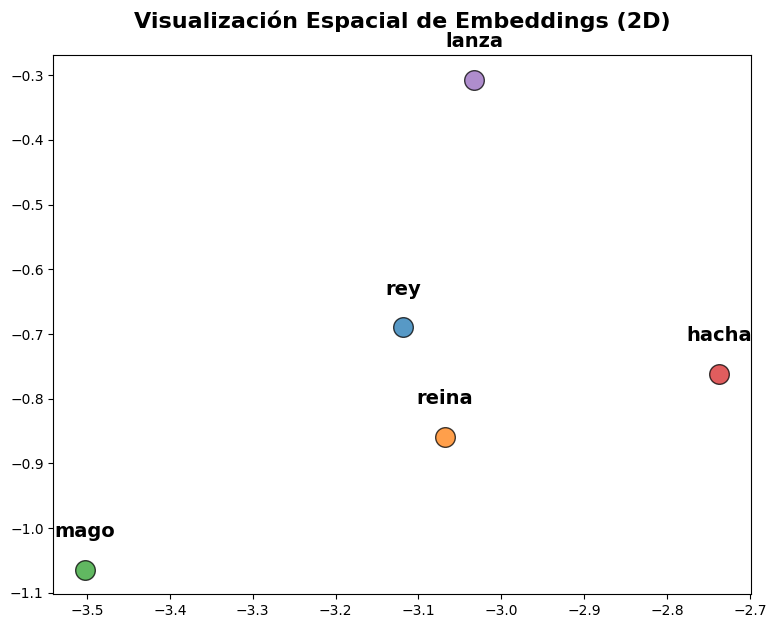

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la función de activación
def sigmoide(x):
    return 1 / (1 + np.exp(-np.clip(x, -10, 10)))

# 2. El nuevo Corpus de 300 oraciones (Muestra reducida para el ejemplo)
entrenamiento_300 = [
    "el rey vive en el palacio", "la reina vive en el palacio", "el principe vive en el palacio",
    "el rey tiene una corona", "la reina tiene una corona", "el principe tiene una corona",
    "el rey gobierna el gran reino", "la reina gobierna el gran reino",
    "el caballero blande una espada", "el soldado blande una espada", "el guerrero blande una espada",
    "el caballero blande un hacha", "el soldado blande un hacha", "el guerrero blande un hacha",
    "la espada es de acero", "el hacha es de acero", "la armadura es de acero",
    "el mago vive en la torre", "el hechicero vive en la torre", "el brujo vive en la torre",
    "el mago lanza un hechizo", "el hechicero lanza un hechizo", "el mago usa su magia",
    "el baston canaliza la magia", "el mago controla el fuego", "el hechicero controla el fuego"
]

# Preprocesamiento y limpieza
corpus_limpio = [oracion.lower().replace(",", "").replace(".", "") for oracion in entrenamiento_300]

# 3. Crear el Vocabulario
palabras = list(set(" ".join(corpus_limpio).split()))
word2idx = {palabra: i for i, palabra in enumerate(palabras)}
vocab_size = len(palabras)

# 4. Hiperparámetros óptimos para las 2 dimensiones
EMBEDDING_DIM = 2
LEARNING_RATE = 0.1
EPOCAS = 3000

# Inicialización de matrices (Foco y Contexto)
np.random.seed(42) # Fijamos semilla para que el gráfico sea siempre igual en clase
W_foco = np.random.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_DIM))
W_contexto = np.random.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_DIM))

# 5. Bucle de Entrenamiento (Skip-Gram)
for epoca in range(EPOCAS):
    for frase in corpus_limpio:
        palabras_frase = frase.split()
        for i, palabra_foco in enumerate(palabras_frase):
            idx_foco = word2idx[palabra_foco]

            # Ventana de contexto de 1 palabra
            vecinos = [palabras_frase[j] for j in [i-1, i+1] if 0 <= j < len(palabras_frase)]

            for vecino in vecinos:
                idx_contexto = word2idx[vecino]

                # Forward Pass
                afinidad = np.dot(W_foco[idx_foco], W_contexto[idx_contexto])
                prediccion = sigmoide(afinidad)

                error = 1.0 - prediccion

                # Backward Pass (Gradientes)
                grad_foco = error * W_contexto[idx_contexto]
                grad_contexto = error * W_foco[idx_foco]

                W_foco[idx_foco] += LEARNING_RATE * grad_foco
                W_contexto[idx_contexto] += LEARNING_RATE * grad_contexto

# 6. Extracción y Visualización de los 6 puntos clave
palabras_clave = ["rey", "reina", "mago", "pueblo", "guerra", "hacha","lanza"]

plt.figure(figsize=(9, 7))

for palabra in palabras_clave:
    if palabra in word2idx:
        idx = word2idx[palabra]
        coordenadas = W_foco[idx]

        # Dibujamos el punto en el mapa
        plt.scatter(coordenadas[0], coordenadas[1], s=200, edgecolors='black', alpha=0.75)

        # Agregamos la etiqueta de texto arriba del punto
        plt.text(coordenadas[0], coordenadas[1] + 0.05, palabra,
                 fontsize=14, fontweight='bold', ha='center')

# Configuración estética del gráfico
plt.title("Visualización Espacial de Embeddings (2D)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel

Es posible ver como con un corpus de 300 oraciones creadas de forma sintetica logramos aproximar la palabra rey a la palabra reyna. Esto se logro con 2 dimenciones, no tiene sentido aumentar la cantidad de dimenciones ya que la finalidad de esto era poder visualizarlo.